# Training the model for Analysis
In this notebook, we will explain how to train your model with the objective of dataset analysis. Here, we optimize to conserve multiple annotations at the same time (e.g. clonotype and cell type, as a surrogate of Gene Expression). You can determine the influence of both modalities (TCR via clonotype, GEX via cell types) by specifying a weight for annotation. This might require retraining on a couple of weight values for finding a mixture suitable for your analysis.

In [1]:
# comet-ml must be imported before torch and sklearn
import comet_ml
import scanpy as sc

import mvtcr.utils_training as utils
utils.fix_seeds(42) #This sets torch.manual_seed, np.random.seed, random.seed for reproducibility; optuna sampler seed can be set later

e:\Anaconda\envs\mvTCR\lib\site-packages\comet_ml\env_logging.py:31: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [3]:
import torch
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [ ]:
# Set display options to fit Cursor display width
import pandas as pd
from IPython.display import display, HTML
import warnings
warnings.filterwarnings('ignore')

# Configure pandas display for wide output
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.expand_frame_repr', False)

# Configure Jupyter notebook display for Cursor
display(HTML("""
<style>
.container { width:100% !important; }
.output_result { max-width: 100% !important; }
.jp-OutputArea-output { max-width: 100% !important; }
.jp-OutputArea { max-width: 100% !important; }
.jp-Cell-outputWrapper { max-width: 100% !important; }
</style>
"""))

print("✓ Display settings configured for Cursor full width output")


## Data Preperation
First we load the data we just created (01_preprocessing notebook) via the Scanpy API. The train-val split is already there.

In [4]:
adata = sc.read_h5ad('p1_preprocessed.h5ad')
print("Data shape:", adata.shape)
print("Columns in obs:", list(adata.obs.columns))
print("Columns in obsm:", list(adata.obsm.keys()))
print("Train/val split:")
print(adata.obs['set'].value_counts())

# Perform basic clustering to create cell type annotations
print("\nPerforming basic clustering...")
sc.pp.neighbors(adata, n_neighbors=15, n_pcs=40)
sc.tl.leiden(adata, resolution=0.5)
adata.obs['full_clustering'] = adata.obs['leiden']
print("Created full_clustering column with values:")
print(adata.obs['full_clustering'].value_counts())

Data shape: (4125, 5000)
Columns in obs: ['mouse_id', 'date', 'tissue', 'sample', 'mouse_BC', 'n_counts', 'log_counts', 'n_genes', 'mt_fraction', 'doublet_score', 'doublet', 'receptor_type', 'receptor_subtype', 'chain_pairing', 'clonotype', 'clonotype_size', 'alpha_len', 'beta_len', 'has_binding', 'set']
Columns in obsm: ['airr', 'alpha_seq', 'beta_seq', 'chain_indices', 'mouse_id_ohe']
Train/val split:
set
train    2466
test      835
val       824
Name: count, dtype: int64

Performing basic clustering...
Created full_clustering column with values:
full_clustering
0    1300
1     752
2     435
3     432
4     406
5     232
6     201
7     141
8     129
9      97
Name: count, dtype: int64


In [5]:
adata

AnnData object with n_obs × n_vars = 4125 × 5000
    obs: 'mouse_id', 'date', 'tissue', 'sample', 'mouse_BC', 'n_counts', 'log_counts', 'n_genes', 'mt_fraction', 'doublet_score', 'doublet', 'receptor_type', 'receptor_subtype', 'chain_pairing', 'clonotype', 'clonotype_size', 'alpha_len', 'beta_len', 'has_binding', 'set', 'leiden', 'full_clustering'
    var: 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
    uns: 'aa_to_id', 'chain_indices', 'clonotype', 'hvg', 'ir_dist_nt_identity', 'log1p', 'mouse_id_colors', 'mouse_id_enc', 'neighbors', 'leiden'
    obsm: 'airr', 'alpha_seq', 'beta_seq', 'chain_indices', 'mouse_id_ohe', 'X_pca'
    obsp: 'distances', 'connectivities'

## Defining the model parameters
We need to proivde the model a couple of parameters:
- study_name: Name for logging
- comet_workspace: we logged some of the experiments via Comet-ML. This gives you more information on the training process, but is not needed. We will therefore use None here. Otherwise, specifiy the workspace name of your Comet-ML project.
- model_name: assigns which model is used from (rna, tcr, moe, poe, concat). We will use the best performing moe.
- balanced_sample: oversample rare elements of this column. Recommended to use a column storing the clonotype to avoid overfitting.
- metadata: annotation to color the umaps when storing immediate results on Comet-ML. If no Comet-ML is used, pass an empty list
- save_path: path to store the trained models over multiple training runs
- conditional: name of a conditional variable (see preprocessing). The model partially removes batch effects over this column.
- n_epoch: amounts of epochs to train the model. For the paper we used 200 epochs. For showcasing however, we will reduce it to 5.

In [6]:
import os

# Create save directory if it doesn't exist
save_path = '../saved_models/haniffa_tutorial'
os.makedirs(save_path, exist_ok=True)

params_experiment = {
    'study_name': 'LEE',
    'comet_workspace': None, 
    'model_name': 'moe',
    'balanced_sampling': 'clonotype',
    'metadata': [],
    'save_path': save_path,
    'conditional': 'mouse_id_ohe',
    'n_epochs': 10,
}

## Defining Optimization parameters
For this analysis, we will optimize to perserve clonotype and cell type ("full_clustering" column in our dataset). This optimization mode is called 'pseudo_metric'. By specifying the weight, we can choose the weighting between both modalities.

In [7]:
params_optimization = {
    'name': 'pseudo_metric',
    'prediction_labels':
        {'clonotype': 1,
         'full_clustering': 1}
}

We also offer the option to exclude cells from evaluation, but not training. To do so, set the value of the prediction label for the desired cells to -99 (in your adata object, not here in the params dict!).

## Calling the training functions
Finally, we need to specificy a couple of parameters for running the training. Training will be aborted either after \<timeout\> seconds or after having trained 3 models with 1 available GPU. Typically, we used considerable larger amount of training runs (e.g. 48 GPU-hours). Note: when increasing the number of GPUs, you will also need to scale the CPU resources, so that the training is not bottlenecked by e.g. dataloading on CPU. The argument sampler_seed can be specified make the optuna sampler behave deterministically. However, for fully reproducible results training should be run sequentially https://optuna.readthedocs.io/en/stable/faq.html.  

In [40]:
from mvtcr.models.model_selection import run_model_selection

# Note: The previous error was due to using 'patient_id_ohe' instead of 'mouse_id_ohe'
# This has been fixed in the params_experiment configuration above
# n_samples specifies the number of Optuna trials (i.e., different hyperparameter configurations) to run during model selection.
# Here, n_samples=3 means that 3 separate trials will be executed to find the best model.

# The training target is to optimize the model to preserve both clonotype
#  and cell type information,
# as specified in the 'params_optimization' dictionary:
# 'prediction_labels': {'clonotype': 1, 'full_clustering': 1}
# This means the model is trained to predict both the clonotype
#  and the cell type ("full_clustering" column).

timeout = (20*60)
n_samples = 1
n_gpus = 1
seed = 42
run_model_selection(adata, params_experiment, params_optimization, n_samples, timeout, n_gpus, sampler_seed=seed)

[I 2025-09-08 20:33:19,935] A new study created in RDB with name: LEE
 60%|██████    | 6/10 [00:11<00:07,  1.87s/it]
[I 2025-09-08 20:33:31,488] Trial 0 finished with value: 0.5915758080072611 and parameters: {'dropout': 0.1, 'activation': 'linear', 'rna_hidden': 1500, 'hdim': 200, 'shared_hidden': 100, 'rna_num_layers': 1, 'tfmr_encoding_layers': 4, 'loss_weights_kl': 4.0428727350273357e-07, 'loss_weights_tcr': 0.034702669886504146, 'lr': 1.0994335574766187e-05, 'zdim': 50, 'tfmr_embedding_size': 16, 'tfmr_num_heads': 8, 'tfmr_dropout': 0.15000000000000002}. Best is trial 0 with value: 0.5915758080072611.


Early stopped
Study statistics:
  Number of finished trials: 1
  Number of pruned trials: 0
  Number of complete trials: 1
Best trial: 
  trial_0
  Value: 0.5915758080072611


### Optuna Dashboard
Optionally you can use Optuna Dashboard to get more insights of e.g. how certain hyperparameters influence model selection. Find more information on how to use it here: https://optuna-dashboard.readthedocs.io/en/latest/getting-started.html

## Output
The console output indicates the best model after Hyperparameter Optimization. We will now load this model and embedd our data with it. Following, we can continue with standard analysis.

In [20]:
path_model = '../saved_models/haniffa_tutorial/trial_2/best_model_by_metric.pt'
model = utils.load_model(adata, path_model)
model

In [34]:
path_model = r'C:\Users\a4945\Desktop\haniffa\haniffa\full\haniffa_tcr_moe_1.pt'
model_ext = torch.load(path_model)
print("Model structure:")
print(f"Model type: {type(model_ext)}")
print(f"\nModel keys: {list(model_ext.keys()) if hasattr(model_ext, 'keys') else 'No keys available'}")

if 'state_dict' in model_ext:
    print(f"\nState dict keys: {list(model_ext['state_dict'].keys())}")

# Print all non-state_dict content
for key, value in model_ext.items():
    if key != 'state_dict':
        print(f"\n{key}:")
        print(value)




Model structure:
Model type: <class 'dict'>

Model keys: ['state_dict', 'train_history', 'val_history', 'aa_to_id', 'params_architecture', 'balanced_sampling', 'metadata', 'conditional', 'optimization_mode_params', 'label_key', 'model_type']

State dict keys: ['theta', 'alpha_encoder.embedding.weight', 'alpha_encoder.positional_encoding.pe', 'alpha_encoder.transformer_encoder.layers.0.self_attn.in_proj_weight', 'alpha_encoder.transformer_encoder.layers.0.self_attn.in_proj_bias', 'alpha_encoder.transformer_encoder.layers.0.self_attn.out_proj.weight', 'alpha_encoder.transformer_encoder.layers.0.self_attn.out_proj.bias', 'alpha_encoder.transformer_encoder.layers.0.linear1.weight', 'alpha_encoder.transformer_encoder.layers.0.linear1.bias', 'alpha_encoder.transformer_encoder.layers.0.linear2.weight', 'alpha_encoder.transformer_encoder.layers.0.linear2.bias', 'alpha_encoder.transformer_encoder.layers.0.norm1.weight', 'alpha_encoder.transformer_encoder.layers.0.norm1.bias', 'alpha_encoder.tra

In [ ]:
    
import torch

ckpt_path = r'C:\Users\a4945\Desktop\7215447\journal\journal\10x\avidity_prediction\10x_avidity_concat_1_0.ckpt'
ckpt = torch.load(ckpt_path, map_location='cpu')

# Print summary (keys and shapes/types, but not actual weights)
print("Checkpoint keys and value types/shapes:")
for k, v in ckpt.items():
    if isinstance(v, dict):
        print(f"{k}: dict with {len(v)} keys")
        for sk, sv in v.items():
            if hasattr(sv, 'shape'):
                print(f"  {sk}: {type(sv).__name__} shape={tuple(sv.shape)}")
            else:
                print(f"  {sk}: {type(sv).__name__}")
    elif hasattr(v, 'shape'):
        print(f"{k}: {type(v).__name__} shape={tuple(v.shape)}")
    else:
        print(f"{k}: {type(v).__name__}")


Checkpoint keys and value types/shapes:
epoch: int
global_step: int
pytorch-lightning_version: str
state_dict: dict with 32 keys
  network.network.0.0.weight: Tensor shape=(900, 45)
  network.network.0.1.weight: Tensor shape=(900,)
  network.network.0.1.bias: Tensor shape=(900,)
  network.network.0.1.running_mean: Tensor shape=(900,)
  network.network.0.1.running_var: Tensor shape=(900,)
  network.network.0.1.num_batches_tracked: Tensor shape=()
  network.network.1.0.weight: Tensor shape=(900, 900)
  network.network.1.1.weight: Tensor shape=(900,)
  network.network.1.1.bias: Tensor shape=(900,)
  network.network.1.1.running_mean: Tensor shape=(900,)
  network.network.1.1.running_var: Tensor shape=(900,)
  network.network.1.1.num_batches_tracked: Tensor shape=()
  network.network.2.0.weight: Tensor shape=(900, 900)
  network.network.2.1.weight: Tensor shape=(900,)
  network.network.2.1.bias: Tensor shape=(900,)
  network.network.2.1.running_mean: Tensor shape=(900,)
  network.network.2.

The data is embedded and the cell annotation is copied to the resulting AnnData object.

In [35]:
latent_moe = model.get_latent(adata, metadata=[], return_mean=True, copy_adata_obs=True)
latent_moe_DF = latent_moe.to_df()
latent_moe_DF

,0,1,2,3,4,5,6,7,8,9
AAACCAAAGGGGAGCT-1_0516_CNS,0.245656,-0.305337,-0.843841,0.048130,0.004990,-0.258269,0.726648,-0.128416,0.124880,-0.135760
AAACCAGCACGTAAAG-1_0516_CNS,-0.852167,0.349132,1.864689,-0.634973,1.020473,-0.056123,-1.109089,-0.393436,1.410357,0.368500
AAACCCATCAGTATCG-1_0516_CNS,-0.243275,-0.433171,1.586133,-1.068931,0.521824,0.569211,-1.324242,-0.516290,1.769516,1.319650
AAACCCCAGCCTAAGC-1_0516_CNS,-1.445001,0.404604,1.550418,-0.796889,0.354708,-0.235295,-1.805712,0.591322,0.987738,-0.112322
AAAGCCGAGAGAGAGA-1_0516_CNS,-1.084924,-0.830372,0.039140,-0.668385,1.648540,0.157940,-1.649413,0.285662,2.198773,0.492713
...,...,...,...,...,...,...,...,...,...,...
GTTGGGCGTACGTGCA-1_0516_SPL,-0.055830,0.408454,0.794092,0.132027,0.036942,0.236525,-1.017097,-0.717280,0.095191,0.301192
GTTGTAAGTAGTGTAC-1_0516_SPL,0.258909,-1.883353,-0.658377,0.716445,0.538991,0.853336,0.560079,-1.416068,0.126460,0.163489
GTTGTATAGGTCAATT-1_0516_SPL,0.384583,0.301251,-0.293810,1.080523,-0.833833,0.294106,0.813593,0.208534,-0.846452,-0.805246
GTTGTCCGTCCTTAAT-1_0516_SPL,0.430535,0.139587,-0.741543,0.713456,-0.038291,-0.203101,0.176962,-0.556507,-0.232910,-0.787887


We can now visualize the data via UMAPs.

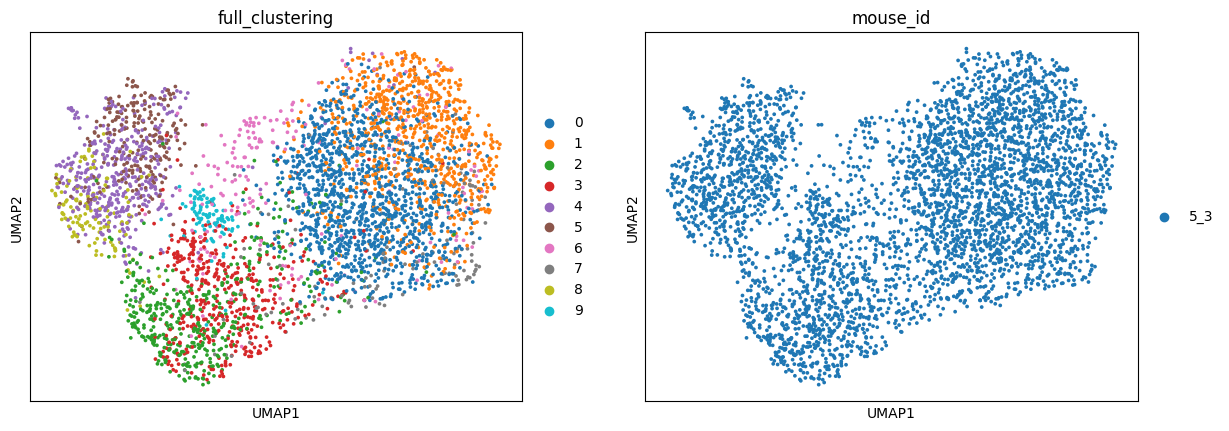

In [ ]:
sc.pp.neighbors(latent_moe, use_rep='X')
sc.tl.umap(latent_moe)
sc.pl.umap(latent_moe, color=['full_clustering', 'mouse_id'])

Note, that the results here show severe batch-effect and bad conservence of cell type. This is due to the limited amount of patients used, the low amount of epochs per training, and the limited runs for HPO. However, these values where choosen in order to have  short computation times for this tutorial.